<hr/>
<b>Nombre</b>: Jesus David Serpa Pajaro
<br/>
<b>Cédula</b>:1192914660
<br/>
<b>Última actualización</b>:
<hr/>

## Enunciado

**Objetivo**: El objetivo de esta tarea es poner en práctica con un problema práctico algunos de los temas vistos sobre el tensor de esfuerzos y el tensor de deformación.

**Procedimiento**:

Un bloque metálico de 2 metros por 1 metro, con 0.2 metros de espesor, esta sometido a un campo de desplazamientos dado por la siguiente expresión:

  $$
  \begin{array}{ll}
x & =X+0.001 Y+0.0002 X^2 - 0.002 Z \\
y & =1.001 Y-0.0002 Y^2 + 0.004 Z \\
z& = 0.0003 X^2 + 0.0004 Y + 0.998 Z
\end{array}
  $$

1. Hacer un mapa de campo vectorial mostrando los vectores de desplazamiento $\vec u$ en la lamina. Es decir, sobre una malla de valores de las coordenadas eulerianas $X, Y$ dibujar el valor del vector de desplazamiento proyectado sobre ese plano $(u_x, u_y)$ para un valor de z específico. Crear un código interactivo que permita, variando el valor de $z$, ver el campo de desplazamientos en la lámina. Hacer lo mismo para cortes en el plano $X-Z$ y $Y-Z$.

2. Calcular el campo tensorial de deformaciones (pequeñas) dentro de la lámina, $u_{ij}$ como función de $\vec X$. Si se diagonaliza el tensor de deformaciones, es posible encontrar en cada punto las denominadas deformaciones principales (autovalores del tensor), $\epsilon_1, \epsilon_2, \epsilon_3$ (de menor a mayor de acuerdo con su valor absoluto) y las direcciones principales de deformación (autovectores normalizados), $\hat e_{u1}, \hat e_{u2}, \hat e_{u3}$. Escriba un código interactivo que permita variar el valor de $X, Y, Z$ y que muestre, en un gráfico en 3-D, las direcciones principales de deformación (son 3 vectores ortogonales) en ese punto de la lámina, de modo que el tamaño de cada vector sea proporcional al valor absoluto de la deformación principal correspondiente. Juegue con el código y comente lo que observa.

3. Consulte el módulo de Young $E$ y el coeficiente de Poisson del Aluminio $\nu$ y, usando la ley de Hooke (relación constitutiva), calcule el tensor de esfuerzos en cada punto del bloque (campo tensorial de esfuerzos) y la presión (campo escalar de presión). Ambos campos deben escribirse como función de $X, Y, Z$. Haga un interactivo en el que muestre, variando el valor de z, un gráfico de contornos (o mapa de calor) de la presión experimentada a cada profundidad dentro del bloque. ¿En que punto del bloque se experimenta la máxima presión y cuánto vale?.

4. Calcule el tensor de esfuerzos en el centro del bloque. Diagonalizando el tensor, determine los esfuerzos principales (autovalores del tensor), $\sigma_1, \sigma_2, \sigma_3$ y las direcciones de los esfuerzos principales (autovectores del tensor normalizados) $\hat e_{\sigma1}, \hat e_{\sigma2}, \hat e_{\sigma3}$. Ahora aplique una rotación del tensor de esfuerzos en ese punto y demuestre que el tensor rotado tiene forma diagonal. Repita el procedimiento de rotación a todos los puntos del bloque y usando esos tensores de esfuerzos rotados, repita 3 (mapas de calor de la presión en el bloque y lugar donde la presión es más grande).

5. Determine el valor del vector de esfuerzo normal (tracción sobre la cara, $\vec t_n = \mathbf{\sigma}\cdot\hat n$) que experimenta el bloque en cada una de sus 6 caras y el esfuerzo normal correspondiente ($\sigma_n = \vec t_n\cdot\hat n$). Haga gráficos de contorno (mapas de calor) para el valor del esfuerzo normal en cada uno de los puntos de esas caras. Comente su resultado.  Calcule también el valor del vector de esfuerzo de cizalladura en cada una de las 3 caras ($\vec\tau_n = \vec t_n - \sigma_n\hat n$) y haga mapas de campo vectorial de esos vectores en cada una de ellas.


## Solución

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact
from sympy import symbols, diff, Matrix
from IPython.display import display, clear_output

1. Hacer un mapa de campo vectorial mostrando los vectores de desplazamiento $\vec u$ en la lamina. Es decir, sobre una malla de valores de las coordenadas eulerianas $X, Y$ dibujar el valor del vector de desplazamiento proyectado sobre ese plano $(u_x, u_y)$ para un valor de z específico. Crear un código interactivo que permita, variando el valor de $z$, ver el campo de desplazamientos en la lámina. Hacer lo mismo para cortes en el plano $X-Z$ y $Y-Z$.

definimos las ecuaciones de los campos de desplazamientos

In [ ]:
def campos(X, Y, Z):
    # Funciones de desplazamiento
    ux = X + 0.001 * Y + 0.0002 * X**2 - 0.002 * Z -X
    uy = 1.001 * Y - 0.0002 * Y**2 + 0.004 * Z - Y
    uz = 0.0003 * X**2 + 0.0004 * Y + 0.998 * Z -Z
    return ux,uy,uz

definimos los campos de desplazamiento para cada uno de los planos

In [ ]:
N= 35
def plano_XY(z):
    X, Y = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 1, N))
    xs, ys, zs = campos(X, Y, z)
    plt.quiver(X, Y, xs, ys, color='k')
    plt.xlabel('Eje X')
    plt.ylabel('Eje Y')
    plt.title('Vector de desplazamiento  ')
    plt.grid()
    plt.show()

def plano_XZ(y):
  X, Z = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 0.2, N))
  xs,ys,zs = campos(X,y,Z)
  plt.quiver(X, Z, xs, zs, color='k')
  plt.xlabel('Eje X')
  plt.ylabel('Eje Y')
  plt.title('Vector de desplazamiento ')
  plt.grid()
  plt.show()

def plano_YZ(x):
  Y, Z = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 0.2, N))
  xs,ys,zs = campos(x,Y,Z)
  plt.quiver(Y, Z, ys, zs, color='k')
  plt.xlabel('Eje X')
  plt.ylabel('Eje Y')
  plt.title('Vector de desplazamiento ')
  plt.grid()
  plt.show()

Para el plano XY

In [ ]:
interact(plano_XY, z=(0, 0.2, 0.01))

interactive(children=(FloatSlider(value=0.1, description='z', max=0.2, step=0.01), Output()), _dom_classes=('w…

<function __main__.plano_XY(z)>

Plano XZ

In [ ]:
interact(plano_XZ, y=(0, 1, 0.01))

interactive(children=(FloatSlider(value=0.0, description='y', max=1.0, step=0.01), Output()), _dom_classes=('w…

<function __main__.plano_XZ(y)>

PLano YZ

In [ ]:
interact(plano_YZ, x=(0, 2, 0.01))

interactive(children=(FloatSlider(value=1.0, description='x', max=2.0, step=0.01), Output()), _dom_classes=('w…

<function __main__.plano_YZ(x)>

2. Calcular el campo tensorial de deformaciones (pequeñas) dentro de la lámina, $u_{ij}$ como función de $\vec X$. Si se diagonaliza el tensor de deformaciones, es posible encontrar en cada punto las denominadas deformaciones principales (autovalores del tensor), $\epsilon_1, \epsilon_2, \epsilon_3$ (de menor a mayor de acuerdo con su valor absoluto) y las direcciones principales de deformación (autovectores normalizados), $\hat e_{u1}, \hat e_{u2}, \hat e_{u3}$. Escriba un código interactivo que permita variar el valor de $X, Y, Z$ y que muestre, en un gráfico en 3-D, las direcciones principales de deformación (son 3 vectores ortogonales) en ese punto de la lámina, de modo que el tamaño de cada vector sea proporcional al valor absoluto de la deformación principal correspondiente. Juegue con el código y comente lo que observa.

In [ ]:
# Definimos las variables
X, Y, Z = symbols('X Y Z')

# Definimos las funciones de desplazamiento
ux = X + 0.001 * Y + 0.0002 * X**2 - 0.002 * Z - X
uy = 1.001 * Y - 0.0002 * Y**2 + 0.004 * Z - Y
uz = 0.0003 * X**2 + 0.0004 * Y + 0.998 * Z - Z

# Calculamos las derivadas parciales
ux_x = (1/2)*(diff(ux, X) + diff(ux, X))
ux_y = (1/2)*(diff(uy, X) + diff(ux, Y))
ux_z = (1/2)*(diff(uz, X) + diff(ux, Z))

uy_x = (1/2)*(diff(ux, Y) + diff(uy, X))
uy_y = (1/2)*(diff(uy, Y) + diff(uy, Y))
uy_z = (1/2)*(diff(uz, Y) + diff(uy, Z))

uz_x = (1/2)*(diff(ux, Z) + diff(uz, X))
uz_y = (1/2)*(diff(uy, Z) + diff(uz, Y))
uz_z = (1/2)*(diff(uz, Z) + diff(uz, Z))

# Creamos la matriz u
M = Matrix([[ux_x, ux_y, ux_z],
                   [uy_x, uy_y, uy_z],
                   [uz_x, uz_y, uz_z]])

M

Matrix([
[        0.0004*X,                         0.0005, 0.0003*X - 0.001],
[          0.0005, 0.00099999999999989 - 0.0004*Y,           0.0022],
[0.0003*X - 0.001,                         0.0022,           -0.002]])

In [ ]:

def deformaciones(X, Y, Z):
    ux, uy, uz = campos(X, Y, Z)

    M = np.array([
        [0.0004*X, 0.0005, 0.0003*X - 0.001],
        [0.0005, 9e-10 - 0.0004*Y, 0.0022],
        [0.0003*X - 0.001, 0.0022, -0.002]
    ])

    autovalores, autovectores = np.linalg.eig(M)
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['m', 'r', 'b']
    ejes = ['X', 'Y', 'Z']
    for i in range(3):
        scale_factor = 100 * np.abs(autovalores[i])
        ax.quiver(X, Y, Z, autovectores[0][i], autovectores[1][i],
                  autovectores[2][i],
                  length=scale_factor, color=colors[i],
                  label=ejes[i])
    ax.set_xlim([0, 2])  #
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 0.5])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title('Deformaciones en función de las coordenadas X, Y y Z')
    plt.legend()
    plt.show()

interact(deformaciones, X=(0, 2, 0.01), Y=(0, 1, 0.01), Z=(0, 0.2, 0.01))

interactive(children=(FloatSlider(value=1.0, description='X', max=2.0, step=0.01), FloatSlider(value=0.0, desc…

<function __main__.deformaciones(X, Y, Z)>

3. Consulte el módulo de Young $E$ y el coeficiente de Poisson del Aluminio $\nu$ y, usando la ley de Hooke (relación constitutiva), calcule el tensor de esfuerzos en cada punto del bloque (campo tensorial de esfuerzos) y la presión (campo escalar de presión). Ambos campos deben escribirse como función de $X, Y, Z$. Haga un interactivo en el que muestre, variando el valor de z, un gráfico de contornos (o mapa de calor) de la presión experimentada a cada profundidad dentro del bloque. ¿En que punto del bloque se experimenta la máxima presión y cuánto vale?.


definimos el modulo de Young y el coeficiente

In [ ]:
E = 70e9  # Pa
υ = 0.35

Definimos la relacion constituviva para calcular el tensor de esfueroz

In [ ]:
def tensoresf(X, Y, Z):

    M = np.array([
        [0.0004 * X, 0.0005, 0.0003 * X - 0.001],
        [0.0005, 9e-10 - 0.0004 * Y, 0.0022],
        [0.0003 * X - 0.001, 0.0022, -0.002]
    ])

    u = np.array([M[0, 0], M[1, 1], M[2, 2], M[0, 1], M[0, 2], M[1, 2]])

    C = E / ((1 + υ) * (1 - 2 * υ))
    R = np.array([
        [(1 - υ), υ, υ, 0, 0, 0],
        [υ, (1 - υ), υ, 0, 0, 0],
        [υ, υ, (1 - υ), 0, 0, 0],
        [0, 0, 0, (1 - 2 * υ) / 2, 0, 0],
        [0, 0, 0, 0, (1 - 2 * υ) / 2, 0],
        [0, 0, 0, 0, 0, (1 - 2 * υ) / 2]
    ]) * C

    #Relacion Constitutiva
    σs = np.dot(R, u)
    σ_11, σ_22, σ_33, σ_12, σ_13, σ_23 = σs

    σ = np.array([
        [σ_11, σ_12, σ_13],
        [σ_12, σ_22, σ_23],
        [σ_13, σ_23, σ_33]
    ])

    P = (-1/3) * np.trace(σ)
    return P,σ

def planotensores_XY(z):
    X, Y = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 1, N))

    P = []
    for i in range(len(X)):
        x = []
        for j in range(len(Y)):
            y,sigma = tensoresf(X[i,j], Y[i,j], z)
            x.append(y)
        P.append(x)

    P = np.array(P)/1e9
    max_P = np.max(P)
    max_indices = np.unravel_index(np.argmax(P), P.shape)

    plt.contourf(X, Y, P, cmap='viridis')
    plt.colorbar(label = 'P [Gpa]')
    plt.scatter(X[max_indices], Y[max_indices], color='red', label=f'Máx: {max_P:.2f}')
    plt.xlabel('Eje X')
    plt.ylabel('Eje Y')
    plt.title('Presion')
    plt.legend()
    plt.show()


interact(planotensores_XY, z=(0, 0.2, 0.01))


interactive(children=(FloatSlider(value=0.1, description='z', max=0.2, step=0.01), Output()), _dom_classes=('w…

<function __main__.planotensores_XY(z)>

4. Calcule el tensor de esfuerzos en el centro del bloque. Diagonalizando el tensor, determine los esfuerzos principales (autovalores del tensor), $\sigma_1, \sigma_2, \sigma_3$ y las direcciones de los esfuerzos principales (autovectores del tensor normalizados) $\hat e_{\sigma1}, \hat e_{\sigma2}, \hat e_{\sigma3}$. Ahora aplique una rotación del tensor de esfuerzos en ese punto y demuestre que el tensor rotado tiene forma diagonal. Repita el procedimiento de rotación a todos los puntos del bloque y usando esos tensores de esfuerzos rotados, repita 3 (mapas de calor de la presión en el bloque y lugar donde la presión es más grande).

calculo el tensor de esfuerzon en el centro del bloque

In [ ]:
P,σ =  tensoresf(1, 0.5, 1)

autoval,autovect = np.linalg.eig(σ)
σrot = autovect.T @ σ @ autovect
σrot

array([[-2.42740182e+08, -1.86264515e-09, -1.49011612e-08],
       [-6.51925802e-09, -8.33206192e+07,  6.84522092e-08],
       [ 7.45058060e-09,  5.54136932e-08, -9.39389890e+07]])

In [ ]:
def Tesfuerzos( X ,Y, Z):
  P,σ =  tensoresf(X,Y,Z)

  autoval,autovect = np.linalg.eig(σ)
  σrot = autovect.T @ σ @ autovect

  P = -(1/3) * np.trace(σrot)
  return P,σrot

In [ ]:
P,σ =  Tesfuerzos(1, 0.5, 1)
σ

array([[-2.42740182e+08, -1.86264515e-09, -1.49011612e-08],
       [-6.51925802e-09, -8.33206192e+07,  6.84522092e-08],
       [ 7.45058060e-09,  5.54136932e-08, -9.39389890e+07]])

In [ ]:
def Tesfuerzos_XY(z):
    X, Y = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 1, N))

    P = []
    for i in range(len(X)):
        x = []
        for j in range(len(Y)):
            p, σrot = Tesfuerzos(X[i, j], Y[i, j], z)
            x.append(np.mean(p))
        P.append(x)
    P = np.array(P)/1e9
    plt.contourf(X, Y, P, cmap='viridis')
    plt.colorbar(label = 'P [Gpa]')
    plt.xlabel('Eje X')
    plt.ylabel('Eje Y')
    plt.title('Presion a partir del tensor de esfuerzo')
    plt.legend()
    plt.show()


interact(Tesfuerzos_XY, z=(0, 0.2, 0.01))

interactive(children=(FloatSlider(value=0.1, description='z', max=0.2, step=0.01), Output()), _dom_classes=('w…

<function __main__.Tesfuerzos_XY(z)>

5. Determine el valor del vector de esfuerzo normal (tracción sobre la cara, $\vec t_n = \mathbf{\sigma}\cdot\hat n$) que experimenta el bloque en cada una de sus 6 caras y el esfuerzo normal correspondiente ($\sigma_n = \vec t_n\cdot\hat n$). Haga gráficos de contorno (mapas de calor) para el valor del esfuerzo normal en cada uno de los puntos de esas caras. Comente su resultado.  Calcule también el valor del vector de esfuerzo de cizalladura en cada una de las 3 caras ($\vec\tau_n = \vec t_n - \sigma_n\hat n$) y haga mapas de campo vectorial de esos vectores en cada una de ellas.


definimos las caras de los bloques

In [ ]:
ns = np.array([[-1,0,0],[1,0,0],
              [0,-1,0],[0,1,0],
              [0,0,-1],[0,0,1]])

In [ ]:
def esfuerzo_cizalladura(X, Y, Z,n):
    P, σ = tensoresf(X, Y, Z)
    t_n = np.dot(σ, n)
    σ_n = np.dot(t_n, n)
    τ_n = t_n - σ_n * n
    return τ_n,σ_n

Para el plano YZ

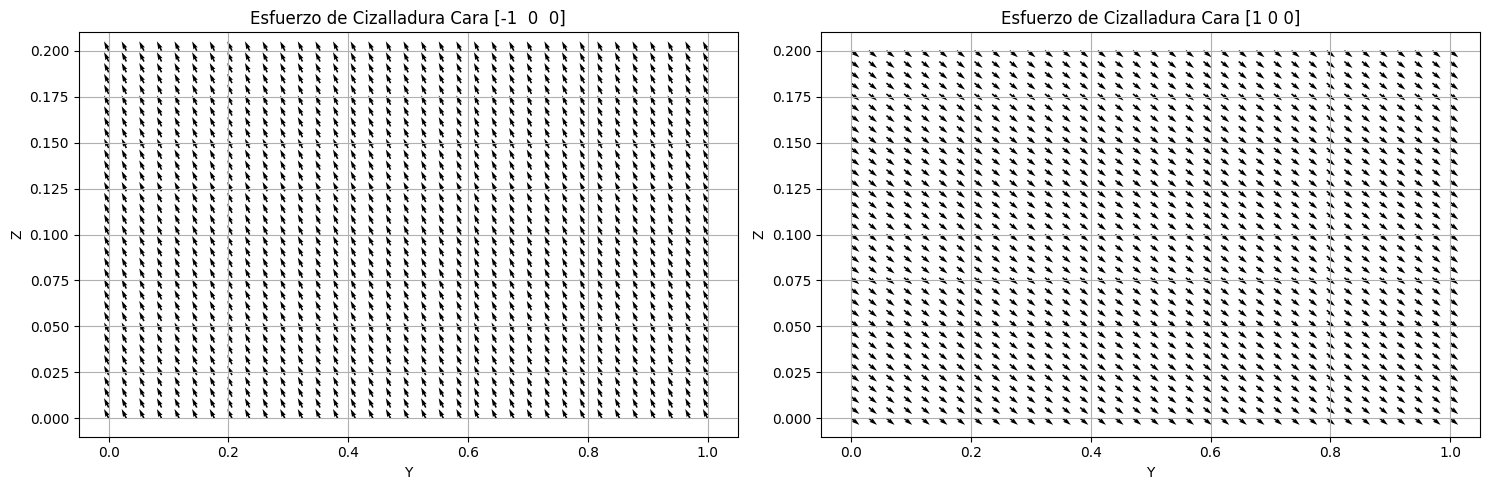

In [ ]:
Y, Z = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 0.2, N))

X = np.array([0,2])
τ_x = []
for i in range(len(X)):
    τx_i = np.zeros((Y.shape[0], Y.shape[1], 3))
    for j in range(Y.shape[0]):
        for k in range(Y.shape[1]):
            τx_i[j, k] = esfuerzo_cizalladura(X[i], Y[j, k], Z[j, k], ns[i])[0]
    τ_x.append(τx_i)

τs_x = np.array(τ_x)

# Crear el gráfico
fig, axs = plt.subplots(1, len(X), figsize=(15, 5))

for i in range(len(X)):
    axs[i].quiver(Y, Z, τ_x[i][:, :, 1], τ_x[i][:, :, 2])
    axs[i].set_xlabel('Y')
    axs[i].set_ylabel('Z')
    axs[i].set_title(f'Esfuerzo de Cizalladura Cara {ns[i]}')
    axs[i].grid()

plt.tight_layout()
plt.show()


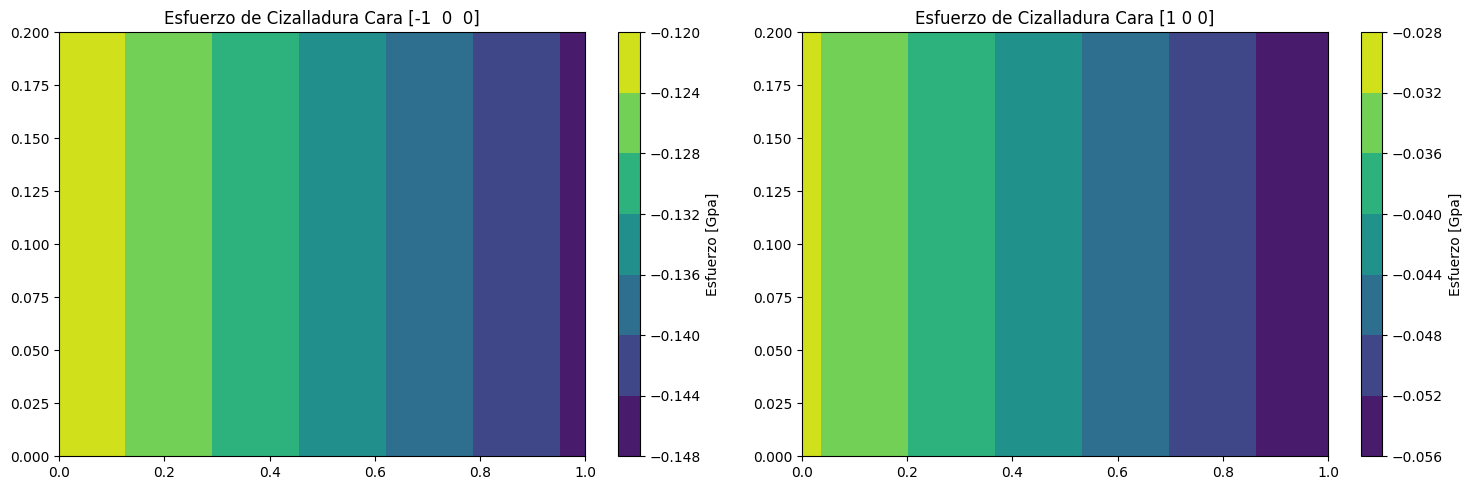

In [ ]:
Y, Z = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 0.2, N))

X = np.array([0,2])
σ_x = []
for i in range(len(X)):
    σx_i = np.zeros((Y.shape[0], Y.shape[1], 3))
    for j in range(Y.shape[0]):
        for k in range(Y.shape[1]):
          σx_i[j, k] = esfuerzo_cizalladura(X[i], Y[j, k], Z[j, k], ns[i])[1]
    σ_x.append(σx_i)

σs_x = np.array(σ_x)/1e9
fig, axs = plt.subplots(1, len(X), figsize=(15, 5))
for i in range(len(X)):
    contorno = axs[i].contourf(Y, Z, σs_x[i][:, :, 0], cmap='viridis')
    axs[i].set_title(f'Esfuerzo de Cizalladura Cara {ns[i]}')
    plt.colorbar(contorno, ax=axs[i], label='Esfuerzo [Gpa]')

plt.tight_layout()
plt.show()

Para el plano XZ

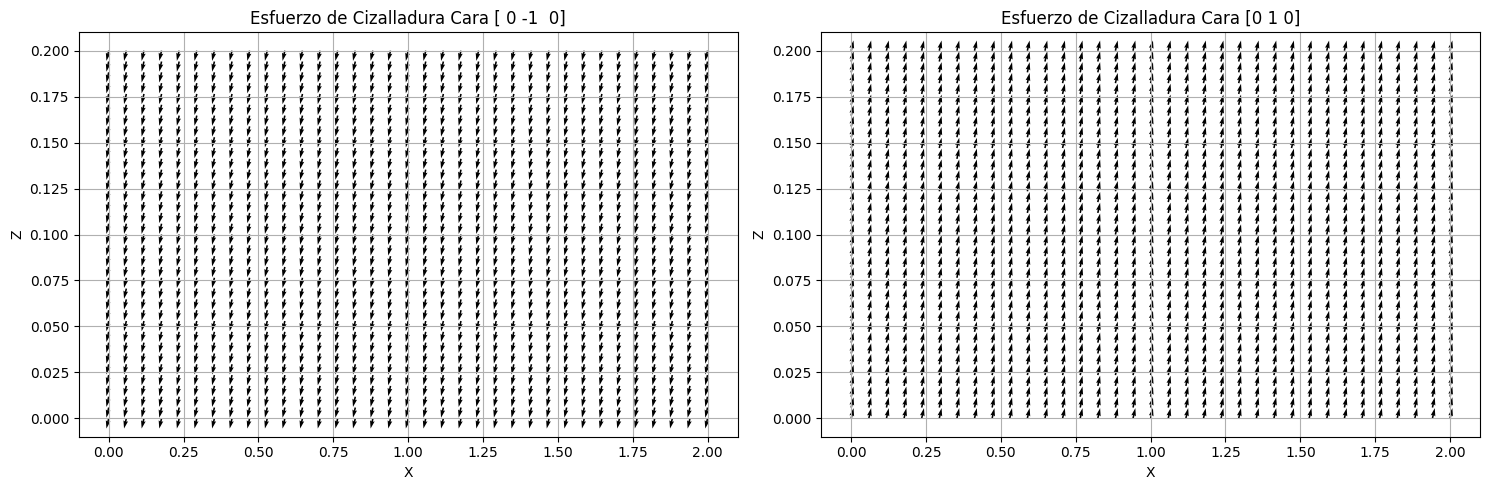

In [ ]:
X, Z = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 0.2, N))

Y = np.array([0,1])
τ_y = []
for i in range(len(Y)):
    τ_y_i = np.zeros((X.shape[0], X.shape[1], 3))
    for j in range(X.shape[0]):
        for k in range(X.shape[1]):
            τ_y_i[j, k] = esfuerzo_cizalladura(X[j,k],Y[i], Z[j, k], ns[i+2])[0]
    τ_y.append(τ_y_i)

τ_y = np.array(τ_y)/1e9

fig, axs = plt.subplots(1, len(Y), figsize=(15, 5))
for i in range(len(Y)):
    axs[i].quiver(X, Z, τ_y[i][:, :, 0], τ_y[i][:, :, 2])
    axs[i].set_xlabel('X')
    axs[i].set_ylabel('Z')
    axs[i].set_title(f'Esfuerzo de Cizalladura Cara {ns[i+2]}')
    axs[i].grid()

plt.tight_layout()
plt.show()


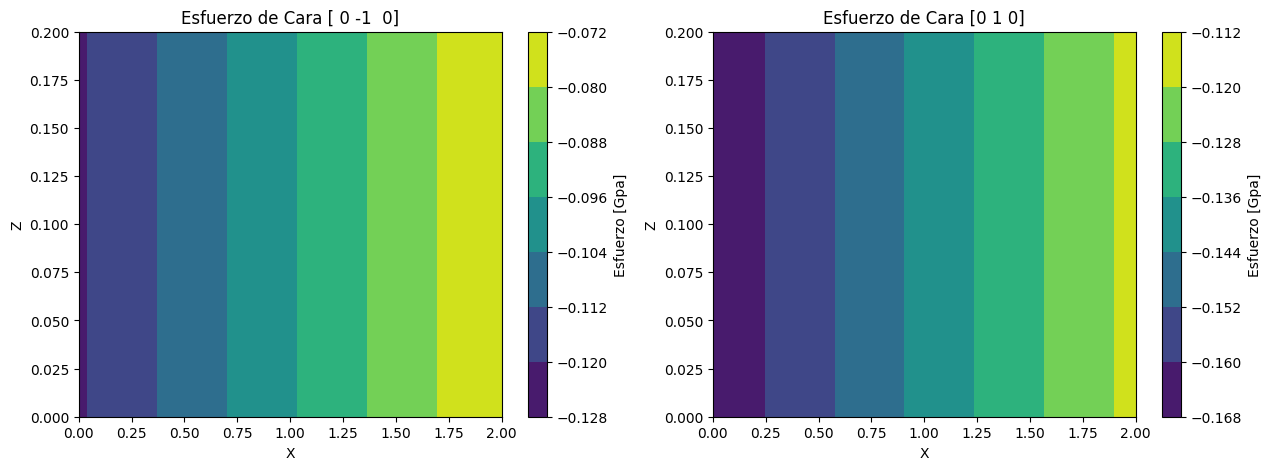

In [ ]:
X, Z = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 0.2, N))

Y = np.array([0,1])
σ_y = []
for i in range(len(Y)):
    σy_i = np.zeros((X.shape[0], X.shape[1], 3))
    for j in range(X.shape[0]):
        for k in range(X.shape[1]):
          σy_i[j, k] = esfuerzo_cizalladura(X[j,k],Y[i], Z[j, k], ns[i+2])[1]
    σ_y.append(σy_i)

σs_y = np.array(σ_y)/1e9
fig, axs = plt.subplots(1, len(Y), figsize=(15, 5))
for i in range(len(Y)):
    contorno = axs[i].contourf(X, Z, σs_y[i][:, :, 1], cmap='viridis')
    axs[i].set_title(f'Esfuerzo de Cara {ns[i+2]}')
    plt.colorbar(contorno, ax=axs[i], label='Esfuerzo [Gpa]')
    axs[i].set_xlabel('X')
    axs[i].set_ylabel('Z')

plt.show()

Para el plano XY

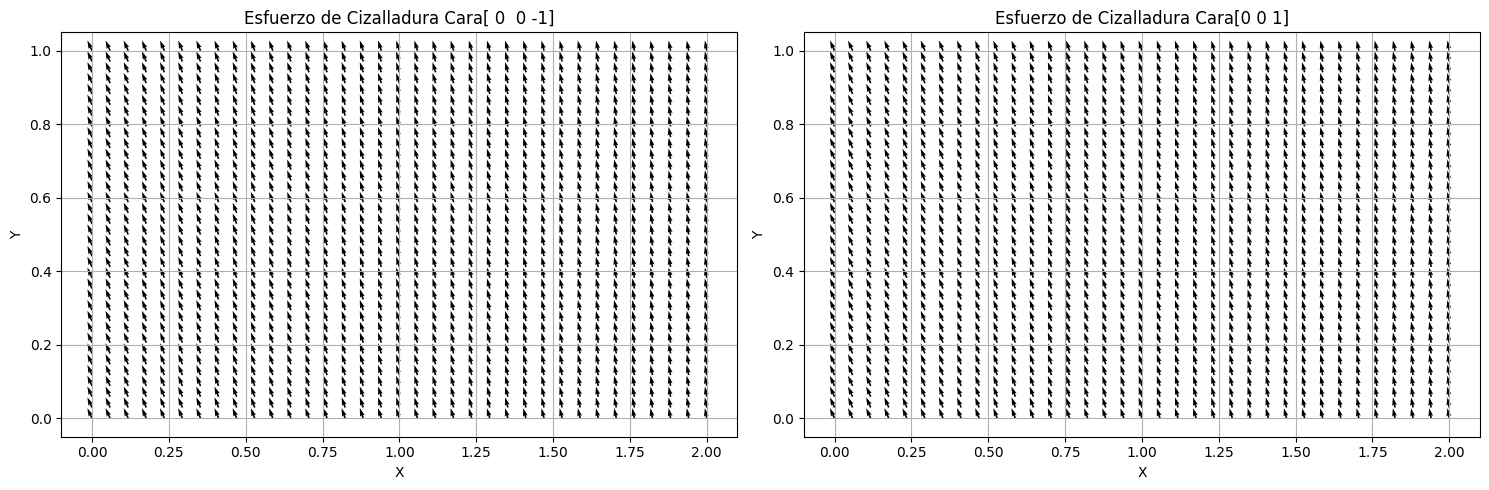

In [ ]:
X, Y = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 1, N))

Z = np.array([0,0.2])
τ_z = []
τns_x_i = np.zeros((X.shape[0], X.shape[1], 3)) ## INTRODUCIDO POR EL PROFESOR
for i in range(len(Z)):
    τ_z_i = np.zeros((X.shape[0], X.shape[1], 3))
    for j in range(X.shape[0]):
        for k in range(X.shape[1]):
            τns_x_i[j, k] = esfuerzo_cizalladura(X[j,k],Y[j, k], Z[i], ns[i+4])[0]
    τ_z.append(τns_x_i)

τ_z = np.array(τ_z)/1e9

fig, axs = plt.subplots(1, len(Z), figsize=(15, 5))
for i in range(len(Z)):
    axs[i].quiver(X, Y, τ_z[i][:, :, 0], τ_z[i][:, :, 1])
    axs[i].set_xlabel('X')
    axs[i].set_ylabel('Y')
    axs[i].set_title(f'Esfuerzo de Cizalladura Cara{ns[i+4]}')
    axs[i].grid()

plt.tight_layout()
plt.show()

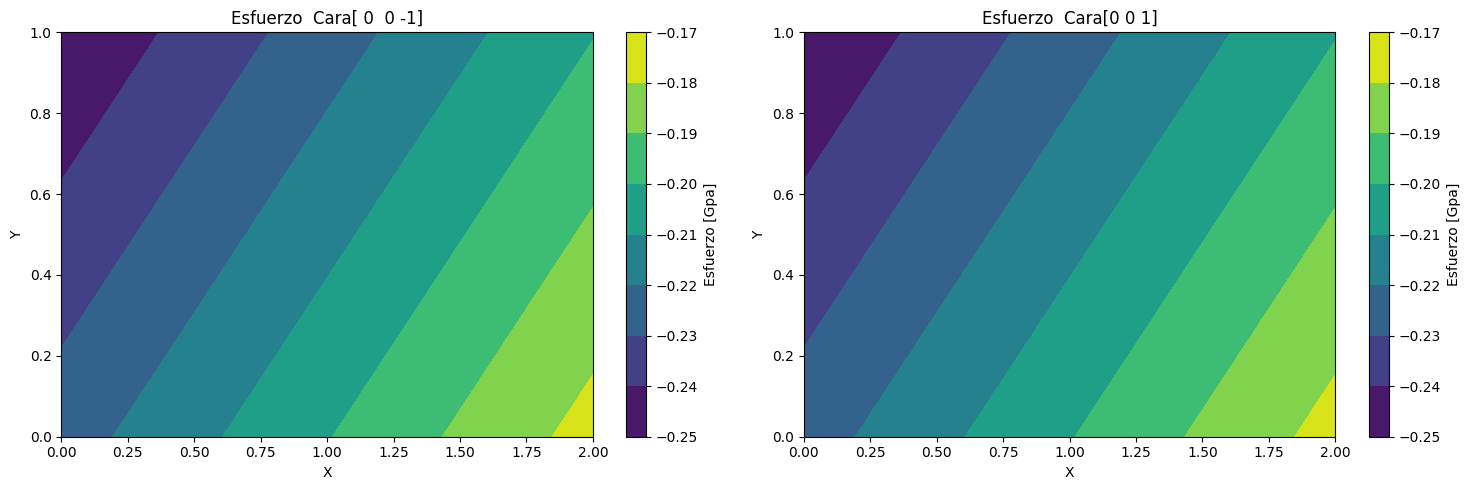

In [ ]:
X, Y = np.meshgrid(np.linspace(0, 2, N), np.linspace(0, 1, N))

Z = np.array([0,0.2])
σ_z = []
for i in range(len(Z)):
    σz_i = np.zeros((X.shape[0], X.shape[1], 3))
    for j in range(X.shape[0]):
        for k in range(X.shape[1]):
          σz_i[j, k] = esfuerzo_cizalladura(X[j,k],Y[j, k], Z[i], ns[i+4])[1]
    σ_z.append(σz_i)

σs_z = np.array(σ_z)/1e9
fig, axs = plt.subplots(1, len(Z), figsize=(15, 5))
for i in range(len(Z)):
    contorno = axs[i].contourf(X, Y, σs_z[i][:, :,2], cmap='viridis')
    axs[i].set_title(f'Esfuerzo  Cara{ns[i+4]}')
    plt.colorbar(contorno, ax=axs[i], label='Esfuerzo [Gpa]')
    axs[i].set_xlabel('X')
    axs[i].set_ylabel('Y')

plt.tight_layout()
plt.show()